# Lab Sheet 6

In [3]:
from header import *

Exercise 1.1

Here are the graphs of $y=x^{n}e^{-x}$ for $n =3,4$ and $5$:

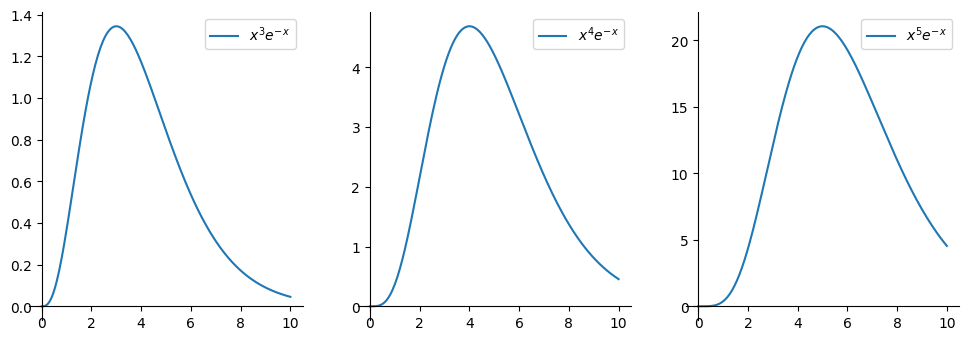

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))
xs = np.linspace(0, 10, 200)
for i, n in enumerate(range(3, 6)):
    ax[i].plot(xs, xs ** n * np.exp(-xs), label = f'$x^{n} e^{{-x}}$')
    fix_axes(ax[i])
    ax[i].legend()

You can just about see that the peaks occur at $x=3$, $x=4$ and $x=5$, suggesting that for general $n$ we should have a peak at $x=n$.  To check this, we must solve $dy/dx=0$.

In [37]:
x = sp.symbols('x')
n = sp.symbols('n', integer=True, positive=True)
y = x ** n * sp.exp(-x)
y1 = sp.simplify(sp.diff(y, x))
x0 = sp.solve([y1],[x])[1][0]
display(Latex(f"The derivative of ${sp.latex(y)}$ is ${sp.latex(y1)}$, and this vanishes at $x={sp.latex(x0)}$"))

<IPython.core.display.Latex object>

In [39]:
y_max = y.subs(x, x0)
display(Latex("The maximum value of $" + sp.latex(y) + "$ is $y_{\\text{max}}=" + sp.latex(y_max) + "$"))
z = sp.simplify(y / y_max)
z_fun = sp.lambdify((n, x), z, 'numpy')
display(Latex("The normalised function $z=y/y_{\\text{max}}$ is given by $" + sp.latex(z) + "$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can plot $z$ for different values of $n$ as shown below.

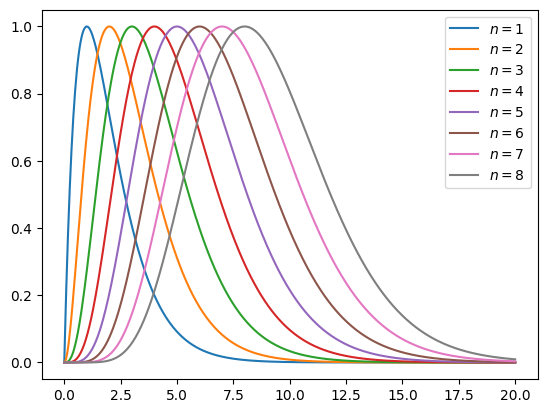

In [40]:
xs = np.linspace(0,20,500)
for n0 in range(1,9):
    plt.plot(xs, z_fun(n0, xs), label = f'$n={n0}$')
plt.legend()


In [8]:
del x

Exercise 1.2

In [44]:
x = sp.symbols('x')
p = -10*x**6+156*x**5-945*x**4+2780*x**3-4080*x**2+2880*x
display(Latex("We consider the function $p(x)=" + sp.latex(p) + "$"))
p1 = sp.diff(p, x)
display(Latex("The derivative of is $p'(x)=" + sp.latex(p1) + "=" + sp.latex(sp.factor(p1)) + "$"))
p2 = sp.diff(p1, x)
p_fun = sp.lambdify(x, p, 'numpy')

root_multiplicities = sp.roots(sp.diff(p, x))
roots = sorted(list(root_multiplicities.keys()))
root_multiplicities = [root_multiplicities[r] for r in roots]
display(Latex(f"The roots of $p'(x)$ are {roots} with multiplicities {root_multiplicities}"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

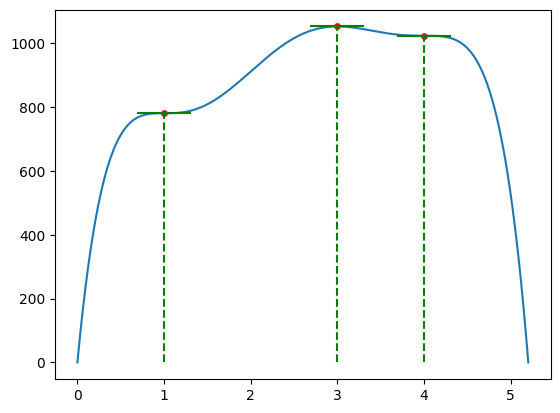

In [10]:
xs = np.linspace(0,5.2023,1000)
plt.plot(xs, p_fun(xs))
for a in roots:
    b = p_fun(a)
    plt.plot([a-0.3, a+0.3],[b,b],'g-')
    plt.plot([a,a],[0,b],'g--')
    plt.scatter(a, b, color='red', s=15)

In [45]:
for a in roots:
    b = p.subs(x, a)
    c = p2.subs(x, a)
    if c < 0:
       t = 'a local maximum'
    elif c > 0:
       t = 'a local minimum'
    else:
       t = 'an inflexion point'
    display(Latex(f"At $x={a}$ we have $p(x)={b}$ and $p''(x)={c}$.  This is {t}."))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [12]:
del x, p, p1, p2, p_fun, a, b, c, roots, root_multiplicities

Exercise 2.1

In [46]:
x, y, t = sp.symbols('x y t')
u = x * sp.sin(x**2 + y**2) - y * sp.cos(x**2 + y**2)
u_fun = sp.lambdify((x, y), u, 'numpy')

<IPython.core.display.Latex object>

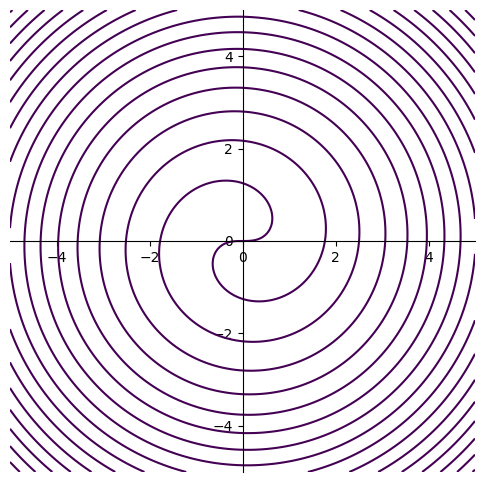

In [48]:
display(Latex("We plot the curve given by $u(x,y)=0$, where $u=" + sp.latex(u) + "$."))
xs, ys = np.meshgrid(np.linspace(-5,5,200), np.linspace(-5,5,200))
zs = u_fun(xs, ys)
fig, ax = plt.subplots(figsize=(6,6))
ax.contour(xs, ys, zs, levels=[0])
fix_axes(ax)
None


The slope of the curve can be given in terms of $x$ and $y$ by implicit differentiation.

In [51]:
slope1 = sp.idiff(u, y, x)
slope1


-(2*x**2*cos(x**2 + y**2) + 2*x*y*sin(x**2 + y**2) + sin(x**2 + y**2))/(2*x*y*cos(x**2 + y**2) + 2*y**2*sin(x**2 + y**2) - cos(x**2 + y**2))

The above expression can be simplified using the fact that $u(x,y)=0$, which gives $\sin(x^2+y^2)=yx^{-1}\cos(x^2+y^2)$.  After making this substitution, all the trigonometric functions cancel out.

In [52]:
slope1 = sp.simplify(slope1.subs(sp.sin(x**2+y**2), y/x*sp.cos(x**2+y**2)))
slope1

(-2*x*(x**2 + y**2) - y)/(x*(2*x*y - 1) + 2*y**3)

In [54]:
xt = t * sp.cos(t**2)
yt = t * sp.sin(t**2)
display(Latex("The curve can also be described parametrically by $x(t)=" + sp.latex(xt) + "$ and $y(t)=" + sp.latex(yt) + "$."))
display(Latex("To verify this, we just need to check that $u(x(t),y(t))=0$."))
sp.simplify(u.subs({x : xt, y : yt}))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

0

The plot below is based on the parametric description; it is visibly the same as the previous plot.

<Axes: >

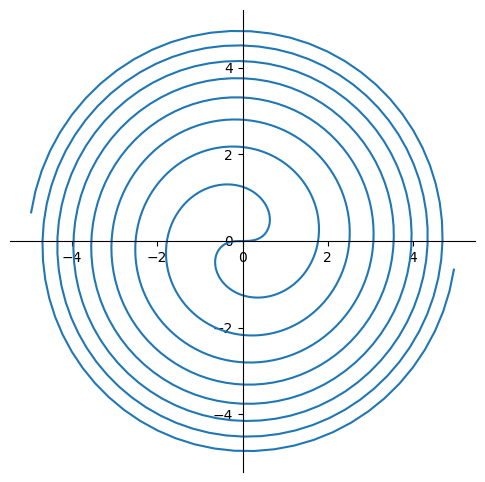

In [17]:
xy_fun = sp.lambdify(t, [xt,yt], 'numpy')
ts = np.linspace(-5,5,1000)
xys = xy_fun(ts)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(xys[0], xys[1])
fix_axes(ax)

From the parametric description we obtain another expression for the slope:

In [55]:
slope2 = yt.diff(t)/xt.diff(t)
slope2

(2*t**2*cos(t**2) + sin(t**2))/(-2*t**2*sin(t**2) + cos(t**2))

The following calculation verifies that the two formulae for the slope are equivalent:

In [56]:
sp.simplify(slope1.subs({x : xt, y : yt}) - slope2)

0

In [20]:
del x, y, t, u, u_fun, xs, ys, zs, xt, yt, xy_fun, ts, xys, slope1, slope2

Exercise 2.2

In [58]:
x, y, t = sp.symbols('x y t')
u = (x**2 + y**2) ** 2 + 85 * (x**2 + y**2) - 500 + 18*x*(3*y**2 - x**2)
u_fun = sp.lambdify((x, y), u, 'numpy')

xt = 6*sp.cos(t) + 8*sp.cos(t)**2 - 4
yt = 2*sp.sin(t)*(3-4*sp.cos(t))
xy_fun = sp.lambdify(t, [xt,yt], 'numpy')


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<Axes: title={'center': 'Parametric plot'}>

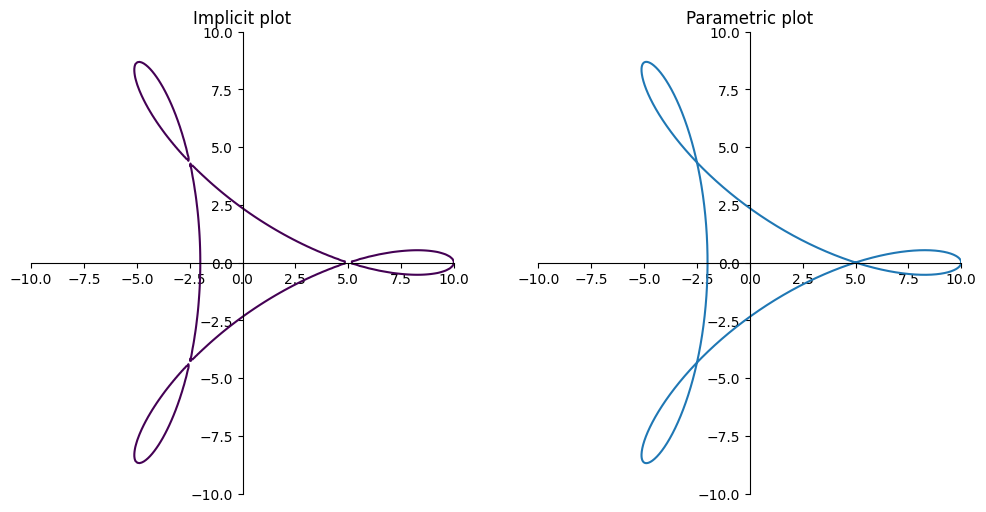

In [59]:
display(Latex("On the left we plot the curve given by $u(x,y)=0$, where $u=" + sp.latex(u) + "$."))
display(Latex("On the right we plot the curve given parametrically by $x(t)=" + sp.latex(xt) + "$ and $y(t)=" + sp.latex(yt) + "$."))

xs, ys = np.meshgrid(np.linspace(-10,10,200), np.linspace(-10,10,200))
zs = u_fun(xs, ys)
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].contour(xs, ys, zs, levels=[0])
ax[0].title.set_text('Implicit plot')
fix_axes(ax[0])
xys = xy_fun(np.linspace(0,2*np.pi,1000))
ax[1].plot(xys[0], xys[1])
ax[1].set_xlim(-10,10)
ax[1].set_ylim(-10,10)
ax[1].title.set_text('Parametric plot')
fix_axes(ax[1])

The following calculation shows that $u(x(t),y(t))=0$, so the two curves are the same.

In [23]:
sp.simplify(sp.expand(u.subs({x : xt, y : yt})))


0

In [65]:
slope1 = sp.simplify(sp.idiff(u, y, x))
display(Latex("Implicit formula for the slope: $$" + sp.latex(slope1) + "$$"))
slope2 = yt.diff(t)/xt.diff(t)
display(Latex("Parametric formula for the slope: $$" + sp.latex(slope2) + "$$"))
err = sp.trigsimp(sp.factor(slope1.subs({x : xt, y : yt}) - slope2))
display(Latex("Consistency check: $" + sp.latex(err) + "$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Exercise 3.1

We define $r(n) = \frac{d^n}{dx^n}\left(\frac{x^n\log(x)}{n!}\right)$

In [66]:
x = sp.symbols('x')

def r(n):
    return sp.diff(x ** n * sp.log(x) / sp.factorial(n),x,n) 

The list $r(0),\dotsc,r(10)$ is as follows:

In [68]:
rr = [r(n) for n in range(0,11)]
rr

[log(x),
 log(x) + 1,
 log(x) + 3/2,
 log(x) + 11/6,
 log(x) + 25/12,
 log(x) + 137/60,
 log(x) + 49/20,
 log(x) + 363/140,
 log(x) + 761/280,
 log(x) + 7129/2520,
 log(x) + 7381/2520]

It seems experimentally that $r(n)-r(n-1)=1/n$, so $r(n)=x+\sum_{k=1}^n\frac{1}{k}$.

In [69]:
rr_dif = [r(n) - r(n-1) for n in range(1,11)]
rr_dif

[1, 1/2, 1/3, 1/4, 1/5, 1/6, 1/7, 1/8, 1/9, 1/10]

The sum can be expressed in terms of 
- A certain constant called `sp.EulerGamma` in `scipy` (or just $\gamma$ in traditional notation) 
- A certain function called `sp.digamma(x)` in `scipy` (or $\Psi(x)$ in traditional notation) 

In [28]:
def r1(n):
    return sp.log(x) + sp.digamma(n+1) + sp.EulerGamma

The calculation below shows that `r(n)=r1(n)` for $n=1,\dotsc,10$.  In fact this holds for all $n$, as one can prove by induction, but we will not give the details here. 


In [29]:
[r(n) - r1(n) for n in range(1,11)]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [30]:
del x, r, rr, rr_dif, r1

Exercise 3.2

Here we aim to find a differential equation that is satisfied by the function $y=t^2 e^t$.  More precisely, we want to find constants $a$, $b$ and $c$ such that $y'''+ay''+by'+cy=0$.

We first take $a$, $b$ and $c$ to be symbols, and calculate $y'''+ay''+by'+cy$.

In [31]:
t, a, b, c = sp.symbols('t a b c')

y = t ** 2 * sp.exp(t)
display(y)
z = sp.simplify(sp.expand(sp.diff(y,t,3) + a * sp.diff(y,t,2) + b * sp.diff(y,t) + c * y))
display(z)

t**2*exp(t)

(a*t**2 + 4*a*t + 2*a + b*t**2 + 2*b*t + c*t**2 + t**2 + 6*t + 6)*exp(t)

The polynomial part of $z$ can be accessed as `z.args[0]`.  We extract the list of coefficients of this polynomial and then use `sp.solve()` to find values of $a$, $b$ and $c$ which make these coefficients equal to zero.

In [32]:
sol = sp.solve(sp.Poly(z.args[0],t).coeffs())
sol

{a: -3, b: 3, c: -1}

The conclusion is that $y'''-3y''+3y'-y=0$.   (The coefficients are the same as in the binomial expansion of $(u-1)^3$.  This is not a coincidence, but we will not explain the reason here.)


In [33]:
del t, a, b, c, y, z, sol

Exercise 3.3

We define 
$$ p(n) = e^{x^2} \frac{d^n}{dx^n}e^{-x^2}. $$

In [70]:
x = sp.symbols('x')

def p(n):
    return sp.expand(sp.exp(x**2)*sp.diff(sp.exp(-x**2),x,n))

We calculate $p(n)$ for $n=0,\dotsc,10$.

In [71]:
for n in range(0,11):
    display(p(n))

1

-2*x

4*x**2 - 2

-8*x**3 + 12*x

16*x**4 - 48*x**2 + 12

...

64*x**6 - 480*x**4 + 720*x**2 - 120

-128*x**7 + 1344*x**5 - 3360*x**3 + 1680*x

256*x**8 - 3584*x**6 + 13440*x**4 - 13440*x**2 + 1680

-512*x**9 + 9216*x**7 - 48384*x**5 + 80640*x**3 - 30240*x

1024*x**10 - 23040*x**8 + 161280*x**6 - 403200*x**4 + 302400*x**2 - 30240

It seems that $p(n)$ is always a polynomial in $x$ with highest term $(-2x)^n$.  

Next, note that when $n$ is even we only get even powers of $x$, and when $n$ is odd we only get odd powers of $x$.  For example, $p(7)$ involves only $x,x^{3},x^{5}$ and $x^{7}$, whereas 
$p (6)$ involves $x^{2},x^{4}$ and $x^{6}$ (and a constant term, which we can think of as a multiple of $x^{0}$).



Now look at the last term in $p(n)$.  When $n$ is even, the last term is a constant, but when $n$ is odd, it is a multiple of 
$x$.  It is best to consider these separately, starting with the even case, where we may write $n=2m$.

We see that the last term is $(-1)^{m}$ times a constant, with the sequence of constants being $1,2,12,120,1680,30240,665280$ and so on.  If we enter this in the [Online Encyclopedia of Integer Sequences](http://www.research.att.com/~njas/sequences/)  we get an answer including the line 

```
A001813: Quadruple factorial numbers: a(n) = (2n)!/n!
```



In [74]:
[p(2*m).subs({x : 0}) for m in range(10)]

[1, -2, 12, -120, 1680, -30240, 665280, -17297280, 518918400, -17643225600]

We can now check directly that the constant term in $p(2m)$ is $(-1)^m(2m)!/m!$, at least for $m<10$:

In [76]:
[(-1)**m * sp.factorial(2*m)/sp.factorial(m) for m in range(10)]

[1, -2, 12, -120, 1680, -30240, 665280, -17297280, 518918400, -17643225600]

Of course this kind of experimental approach does not really prove that the formula is correct, but it is very suggestive.
